In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pymcel as pc
import rebound as rb
import plotly.graph_objects as go
from celluloid import Camera

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


### <span style="color:red">Clase 6: Sistema de Unidades Canónicas para Integración N-Cuerpos</span>

Para garantizar la estabilidad numérica durante la integración de las ecuaciones de movimiento, es imperativo realizar una adimensionalización del sistema. En mecánica celeste, esto se logra definiendo un sistema de unidades canónicas donde la constante de gravitación universal es $G = 1$.

Definimos nuestras unidades fundamentales de masa ($MU$) y distancia ($DU$) basadas en el sistema heliocéntrico:
* **Unidad de Masa (MU):** $1 \, M_{\odot}$ (Masa Solar)
* **Unidad de Distancia (DU):** $1 \, \text{AU}$ (Unidad Astronómica)

Para que la ecuación de movimiento $\ddot{\mathbf{r}} = -G \frac{M}{r^3} \mathbf{r}$ retenga su forma sin el factor $G$, la unidad de tiempo ($TU$) queda rígidamente determinada por el análisis dimensional:

$$TU = \sqrt{\frac{DU^3}{G \cdot MU}}$$

Sustituyendo los valores en el Sistema Internacional (SI):

$$TU = \sqrt{\frac{(1.495978707 \times 10^{11} \, \text{m})^3}{(6.67430 \times 10^{-11} \, \text{m}^3 \text{kg}^{-1} \text{s}^{-2}) (1.98847 \times 10^{30} \, \text{kg})}} \approx 5.022 \times 10^6 \, \text{s}$$

Esto equivale aproximadamente a **58.132 días**. Esta unidad canónica de tiempo es el factor de escala de la simulación, mientras que las épocas de los eventos astronómicos se seguirán registrando en **Tiempo Juliano (JD)** para referenciar las fechas calendario reales del acercamiento de Apophis.

Por lo tanto, la unidad de velocidad canónica ($VU$) se define como:

$$VU = \frac{DU}{TU} \approx 29.78 \, \text{km/s}$$

Al usar este sistema, la Tierra viaja aproximadamente a $1 \, VU$ y la distancia Tierra-Sol es $1 \, DU$, manteniendo todos los valores de las matrices de estado en órdenes de magnitud cercanos a la unidad y evitando inestabilidades numéricas.

In [2]:
# Entonces, el sistema de unidades:

G_canon = 1 # Gravitational constant
M_canon = 1 # Mass Unit
D_canon = 1 # Distance unit

G = pc.constantes.G
MU = pc.constantes.M_sun
AU = pc.constantes.au

T_canon = np.sqrt(AU**3/(G*MU)) # Time unit
V_canon = AU/T_canon # Velocity unit

### Clase 6

Se debe de trabajar con unidades canónicas, y jugar un poquito con ellas !!

 - `tabla_*` keeps the original Horizons units (often AU and AU/day).
 - `pos_vel_*` is converted by pymcel to SI by default: meters and meters/second.
 Convention: state = [x, y, z, vx, vy, vz] (barycentric because location='@0')

Mass from https://www.esa.int/Space_Safety/Planetary_Defence/Apophis

In [3]:
# Apophis
tabla_apophis, jd_apophis, pos_vel_apophis = pc.consulta_horizons(id = "99942", location = "@0", epochs = "2028-01-01")
pos_vel_apophis = pos_vel_apophis / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

mass_apophis = 18143694800 # kg, estimated mass of Apophis
masa_apophis = mass_apophis / MU # Convert to canonical mass units

In [4]:
# Se crea entonces un sistema (de 2 cuerpitos mientras :p)

sistema = [
    dict(m = 1, r = [0,0,0], v = [0,0,0]), # Sun
    dict(m = masa_apophis, r = pos_vel_apophis[:3].tolist(), v = pos_vel_apophis[3:].tolist())  # Apophis
]

steps = 600

ts = np.linspace(0,10,steps)
rs, vs, rps, vps, constantes = pc.ncuerpos_solucion(sistema, ts)


In [5]:
# graph !
fig = go.Figure()
fig.add_trace(go.Scatter3d(x=rs[0][:,0], y=rs[0][:,1], z=rs[0][:,2], mode='lines', name='Cuerpo 1'))
fig.add_trace(go.Scatter3d(x=rs[1][:,0], y=rs[1][:,1], z=rs[1][:,2], mode='lines', name='Cuerpo 2'))
fig.update_layout(title='Trayectorias de los cuerpos', scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'))
fig.update_layout(scene=dict(aspectmode='data'))
fig.show()

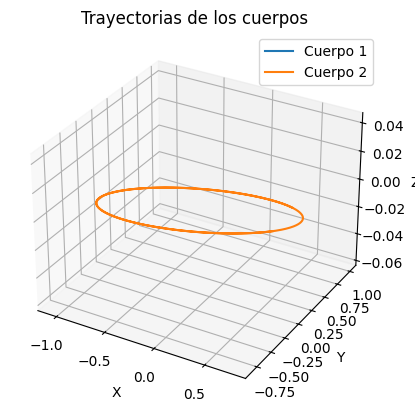

In [6]:
# 3d graph with matplotlib
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(rs[0][:,0], rs[0][:,1], rs[0][:,2], label='Cuerpo 1') # Cuerpo 0 = sol
ax.plot(rs[1][:,0], rs[1][:,1], rs[1][:,2], label='Cuerpo 2') # Cuerpo 1 = Apophis
ax.set_title('Trayectorias de los cuerpos') 
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()


In [7]:
# Cuadraturas !!

# Momento angular total del sistema
suma = 0
for i in range(len(sistema)):
    suma += (sistema [i]['m'] * np.cross(rs[i, 12, :], vs[i, 12, :]))
print(suma)

# Momento lineal total del sistema
suma = 0
for i in range(len(sistema)):
    suma += (sistema [i]['m'] * vs[i, 42, :])

print(suma)

# Interpretar esto luegoo i guess

[-2.01854018e-22  4.58200185e-22  8.55965098e-21]
[-8.68453113e-21  2.85269152e-21 -3.57504212e-22]


### Clase 9

In [8]:
# Rebound simulation

sim= rb.Simulation()

sim.add(m=1, x=0, y=0, z=0, vx=0, vy=0, vz=0) # Sol
sim.add(m=masa_apophis, x=pos_vel_apophis[0], y=pos_vel_apophis[1], z=pos_vel_apophis[2], vx=pos_vel_apophis[3], vy=pos_vel_apophis[4], vz=pos_vel_apophis[5]) # Apophis

# Integrate

rps = np.zeros((2, steps, 3))
vps = np.zeros((2, steps, 3))
rs = np.zeros((2, steps, 3))
vs = np.zeros((2, steps, 3))
sim.move_to_com()

for i, t in enumerate(ts):
    sim.integrate(t)
    for j in range(2):
        rs[j,i] = sim.particles[j].xyz
        vs[j,i] = sim.particles[j].vxyz

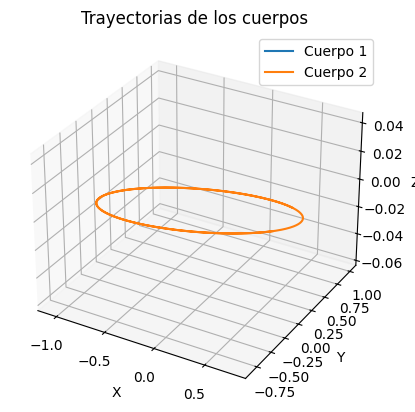

In [9]:
# 3d graph with matplotlib
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(rs[0][:,0], rs[0][:,1], rs[0][:,2], label='Cuerpo 1') # Cuerpo 0 = sol
ax.plot(rs[1][:,0], rs[1][:,1], rs[1][:,2], label='Cuerpo 2') # Cuerpo 1 = Apophis
ax.set_title('Trayectorias de los cuerpos') 
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

In [10]:
# Tierra

tabla_tierra, jd_tierra, pos_vel_tierra = pc.consulta_horizons(id = "399", location = "@0", epochs = "2028-01-01")
pos_vel_tierra = pos_vel_tierra / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_tierra = pc.constantes.M_earth / MU # Convert to canonical mass units

# Se crea entonces un sistema (de 3 cuerpitos)

# Rebound simulation

sim= rb.Simulation()

sim.add(m=1, x=0, y=0, z=0, vx=0, vy=0, vz=0) # Sol
sim.add(m=masa_apophis, x=pos_vel_apophis[0], y=pos_vel_apophis[1], z=pos_vel_apophis[2], vx=pos_vel_apophis[3], vy=pos_vel_apophis[4], vz=pos_vel_apophis[5]) # Apophis
sim.add(m=masa_tierra, x=pos_vel_tierra[0], y=pos_vel_tierra[1], z=pos_vel_tierra[2], vx=pos_vel_tierra[3], vy=pos_vel_tierra[4], vz=pos_vel_tierra[5]) # Tierra
sim.move_to_com()

# Integrate

rps = np.zeros((3, steps, 3))
vps = np.zeros((3, steps, 3))
rs = np.zeros((3, steps, 3))
vs = np.zeros((3, steps, 3))

for i, t in enumerate(ts):
    sim.integrate(t)
    for j in range(3):
        rs[j,i] = sim.particles[j].xyz
        vs[j,i] = sim.particles[j].vxyz

In [11]:
# graph !
fig = go.Figure()
fig.add_trace(go.Scatter3d(x=rs[0][:,0], y=rs[0][:,1], z=rs[0][:,2], mode='lines', name='Sol'))
fig.add_trace(go.Scatter3d(x=rs[1][:,0], y=rs[1][:,1], z=rs[1][:,2], mode='lines', name='Apophis'))
fig.add_trace(go.Scatter3d(x=rs[2][:,0], y=rs[2][:,1], z=rs[2][:,2], mode='lines', name='Tierra'))
fig.update_layout(title='Trayectorias de los cuerpos', scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'))
fig.update_layout(scene=dict(aspectmode='data'))
fig.show()

In [12]:
# Calculamos la distancia minima entre Apophis y la Tierra durante la simulación
distancias = np.linalg.norm(rs[1] - rs[2], axis=1)
distancia_minima = np.min(distancias)
print(f"Distancia mínima entre Apophis y la Tierra: {distancia_minima * AU / 1000} km")

# La fecha de la distancia mínima se puede estimar encontrando el índice de la distancia mínima y luego usando ese índice para encontrar el tiempo correspondiente en el array de tiempos `ts`.

# Fecha de la distancia mínima
indice_minimo = np.argmin(distancias)
fecha_minima = ts[indice_minimo] * T_canon / (24 * 3600) # Convertir tiempo canónico a días
print(f"Fecha de la distancia mínima: {fecha_minima} días")

# 463 días desde el 1 de enero son entonces

fecha_minima_fecha = np.datetime64('2028-01-01') + np.timedelta64(int(fecha_minima), 'D')
print(f"Fecha de la distancia mínima: {fecha_minima_fecha}")

Distancia mínima entre Apophis y la Tierra: 68226.98578774072 km
Fecha de la distancia mínima: 463.8949372093495 días
Fecha de la distancia mínima: 2029-04-08


In [ ]:
# Now we add all the planets + moon

# Internos

tabla_mercurio, jd_mercurio, pos_vel_mercurio = pc.consulta_horizons(id = "199", location = "@0", epochs = "2028-01-01")
pos_vel_mercurio = pos_vel_mercurio / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_mercurio = (pc.constantes.mu_mercury)/G / MU # Convert to canonical mass units

tabla_venus, jd_venus, pos_vel_venus = pc.consulta_horizons(id = "299", location = "@0", epochs = "2028-01-01")
pos_vel_venus = pos_vel_venus / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_venus = (pc.constantes.mu_venus)/G / MU # Convert to canonical mass units

# Externos

tabla_marte, jd_marte, pos_vel_marte = pc.consulta_horizons(id = "499", location = "@0", epochs = "2028-01-01")
pos_vel_marte = pos_vel_marte / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_marte = (pc.constantes.mu_mars)/G / MU # Convert to canonical mass units

tabla_jupiter, jd_jupiter, pos_vel_jupiter = pc.consulta_horizons(id = "599", location = "@0", epochs = "2028-01-01")
pos_vel_jupiter = pos_vel_jupiter / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_jupiter = pc.constantes.M_jup / MU # Convert to canonical mass units

tabla_saturno, jd_saturno, pos_vel_saturno = pc.consulta_horizons(id = "699", location = "@0", epochs = "2028-01-01")
pos_vel_saturno = pos_vel_saturno / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_saturno = (pc.constantes.mu_saturn)/G / MU # Convert to canonical mass units

tabla_urano, jd_urano, pos_vel_urano = pc.consulta_horizons(id = "799", location = "@0", epochs = "2028-01-01")
pos_vel_urano = pos_vel_urano / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_urano = (pc.constantes.mu_uranus)/G / MU # Convert to canonical mass units

tabla_neptuno, jd_neptuno, pos_vel_neptuno = pc.consulta_horizons(id = "899", location = "@0", epochs = "2028-01-01")
pos_vel_neptuno = pos_vel_neptuno / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_neptuno = (pc.constantes.mu_neptune)/G / MU # Convert to canonical mass units

# Luna

tabla_luna, jd_luna, pos_vel_luna = pc.consulta_horizons(id = "301", location = "@0", epochs = "2028-01-01")
pos_vel_luna = pos_vel_luna / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_luna = (pc.constantes.mu_moon)/G / MU # Convert to canonical mass units

In [14]:
# Rebound simulation

bodies = 11

# Rebound simulation

sim= rb.Simulation()

sim.add(m=1, x=0, y=0, z=0, vx=0, vy=0, vz=0) # Sol
sim.add(m=masa_apophis, x=pos_vel_apophis[0], y=pos_vel_apophis[1], z=pos_vel_apophis[2], vx=pos_vel_apophis[3], vy=pos_vel_apophis[4], vz=pos_vel_apophis[5]) # Apophis
sim.add(m=masa_tierra, x=pos_vel_tierra[0], y=pos_vel_tierra[1], z=pos_vel_tierra[2], vx=pos_vel_tierra[3], vy=pos_vel_tierra[4], vz=pos_vel_tierra[5]) # Tierra
sim.add(m=masa_mercurio, x=pos_vel_mercurio[0], y=pos_vel_mercurio[1], z=pos_vel_mercurio[2], vx=pos_vel_mercurio[3], vy=pos_vel_mercurio[4], vz=pos_vel_mercurio[5]) # Mercurio
sim.add(m=masa_venus, x=pos_vel_venus[0], y=pos_vel_venus[1], z=pos_vel_venus[2], vx=pos_vel_venus[3], vy=pos_vel_venus[4], vz=pos_vel_venus[5]) # Venus
sim.add(m=masa_marte, x=pos_vel_marte[0], y=pos_vel_marte[1], z=pos_vel_marte[2], vx=pos_vel_marte[3], vy=pos_vel_marte[4], vz=pos_vel_marte[5]) # Marte
sim.add(m=masa_jupiter, x=pos_vel_jupiter[0], y=pos_vel_jupiter[1], z=pos_vel_jupiter[2], vx=pos_vel_jupiter[3], vy=pos_vel_jupiter[4], vz=pos_vel_jupiter[5]) # Jupiter
sim.add(m=masa_saturno, x=pos_vel_saturno[0], y=pos_vel_saturno[1], z=pos_vel_saturno[2], vx=pos_vel_saturno[3], vy=pos_vel_saturno[4], vz=pos_vel_saturno[5]) # Saturno
sim.add(m=masa_urano, x=pos_vel_urano[0], y=pos_vel_urano[1], z=pos_vel_urano[2], vx=pos_vel_urano[3], vy=pos_vel_urano[4], vz=pos_vel_urano[5]) # Urano
sim.add(m=masa_neptuno, x=pos_vel_neptuno[0], y=pos_vel_neptuno[1], z=pos_vel_neptuno[2], vx=pos_vel_neptuno[3], vy=pos_vel_neptuno[4], vz=pos_vel_neptuno[5]) # Neptuno
sim.add(m=masa_luna, x=pos_vel_luna[0], y=pos_vel_luna[1], z=pos_vel_luna[2], vx=pos_vel_luna[3], vy=pos_vel_luna[4], vz=pos_vel_luna[5]) # Luna
sim.move_to_com()

# Integrate

steps = 1500
ts = np.linspace(0,10,steps)

rps = np.zeros((bodies, steps, 3))
vps = np.zeros((bodies, steps, 3))
rs = np.zeros((bodies, steps, 3))
vs = np.zeros((bodies, steps, 3))

for i, t in enumerate(ts):
    sim.integrate(t)
    for j in range(bodies):
        rs[j,i] = sim.particles[j].xyz
        vs[j,i] = sim.particles[j].vxyz

In [15]:
# graph !
fig = go.Figure()
fig.add_trace(go.Scatter3d(x=rs[0][:,0], y=rs[0][:,1], z=rs[0][:,2], mode='lines', name='Sol'))
fig.add_trace(go.Scatter3d(x=rs[1][:,0], y=rs[1][:,1], z=rs[1][:,2], mode='lines', name='Apophis'))
fig.add_trace(go.Scatter3d(x=rs[2][:,0], y=rs[2][:,1], z=rs[2][:,2], mode='lines', name='Tierra'))
fig.add_trace(go.Scatter3d(x=rs[3][:,0], y=rs[3][:,1], z=rs[3][:,2], mode='lines', name='Mercurio'))
fig.add_trace(go.Scatter3d(x=rs[4][:,0], y=rs[4][:,1], z=rs[4][:,2], mode='lines', name='Venus'))
fig.add_trace(go.Scatter3d(x=rs[5][:,0], y=rs[5][:,1], z=rs[5][:,2], mode='lines', name='Marte'))
fig.add_trace(go.Scatter3d(x=rs[6][:,0], y=rs[6][:,1], z=rs[6][:,2], mode='lines', name='Jupiter'))
#fig.add_trace(go.Scatter3d(x=rs[7][:,0], y=rs[7][:,1], z=rs[7][:,2], mode='lines', name='Saturno'))
#fig.add_trace(go.Scatter3d(x=rs[8][:,0], y=rs[8][:,1], z=rs[8][:,2], mode='lines', name='Urano'))
#fig.add_trace(go.Scatter3d(x=rs[9][:,0], y=rs[9][:,1], z=rs[9][:,2], mode='lines', name='Neptuno'))
fig.add_trace(go.Scatter3d(x=rs[10][:,0], y=rs[10][:,1], z=rs[10][:,2], mode='lines', name='Luna'))
fig.update_layout(title='Trayectorias de los cuerpos', scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'))
fig.update_layout(scene=dict(aspectmode='data'))
fig.show()

In [16]:
# Calculamos la distancia minima entre Apophis y la Tierra durante la simulación
distancias = np.linalg.norm(rs[1] - rs[2], axis=1)
distancia_minima = np.min(distancias)
print(f"Distancia mínima entre Apophis y la Tierra: {distancia_minima * AU / 1000} km")

# La fecha de la distancia mínima se puede estimar encontrando el índice de la distancia mínima y luego usando ese índice para encontrar el tiempo correspondiente en el array de tiempos `ts`.

# Fecha de la distancia mínima
indice_minimo = np.argmin(distancias)
fecha_minima = ts[indice_minimo] * T_canon / (24 * 3600) # Convertir tiempo canónico a días
print(f"Fecha de la distancia mínima: {fecha_minima} días")

# 463 días desde el 1 de enero son entonces

fecha_minima_fecha = np.datetime64('2028-01-01') + np.timedelta64(int(fecha_minima), 'D')
print(f"Fecha de la distancia mínima: {fecha_minima_fecha}")

Distancia mínima entre Apophis y la Tierra: 747916.0883871836 km
Fecha de la distancia mínima: 463.4307328025356 días
Fecha de la distancia mínima: 2029-04-08


In [17]:
# Now we also add the next 5 most massive asteroids (Ceres, Pallas, Vesta, Hygiea, Interamnia) and see if they have any effect on the distance minimum between Apophis and Earth. We can also add some of the most massive TNOs (Pluto, Eris, Haumea, Makemake) just for fun.

tabla_ceres, jd_ceres, pos_ceres = pc.consulta_horizons(id = "ceres", location = "@0", epochs = "2028-01-01")
mass_ceres = 9.393e20 # kg, estimated mass of Ceres
mass_ceres_canon = mass_ceres / MU # Convert to canonical mass units
pos_vel_ceres = pos_ceres / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

tabla_pallas, jd_pallas, pos_pallas = pc.consulta_horizons(id = "pallas", location = "@0", epochs = "2028-01-01")
mass_pallas = 2.14e20 # kg, estimated mass of Pallas
mass_pallas_canon = mass_pallas / MU
pos_vel_pallas = pos_pallas / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

tabla_vesta, jd_vesta, pos_vesta = pc.consulta_horizons(id = "vesta", location = "@0", epochs = "2028-01-01")
mass_vesta = 2.59e20 # kg, estimated mass of Vesta
mass_vesta_canon = mass_vesta / MU
pos_vel_vesta = pos_vesta / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

tabla_Hygiea, jd_hygiea, pos_hygiea = pc.consulta_horizons(id = "hygiea", location = "@0", epochs = "2028-01-01")
mass_hygiea = 8.32e19 # kg, estimated mass of Hyg
mass_hygiea_canon = mass_hygiea / MU
pos_vel_hygiea = pos_hygiea / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

tabla_interamnia, jd_interamnia, pos_interamnia = pc.consulta_horizons(id = "interamnia", location = "@0", epochs = "2028-01-01")
mass_interamnia = 3.9e19 # kg, estimated mass of Interam
mass_interamnia_canon = mass_interamnia / MU
pos_vel_interamnia = pos_interamnia / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

In [18]:
#we make yet another system

names = ['Sol', 'Apophis', 'Tierra', 'Mercurio', 'Venus', 'Marte', 'Jupiter', 'Saturno', 'Urano', 'Neptuno', 'Luna', 'Ceres', 'Pallas', 'Vesta', 'Hygiea', 'Interamnia']

bodies = 16

# Rebound simulation

sim= rb.Simulation()

sim.add(m=1, x=0, y=0, z=0, vx=0, vy=0, vz=0) # Sol
sim.add(m=masa_apophis, x=pos_vel_apophis[0], y=pos_vel_apophis[1], z=pos_vel_apophis[2], vx=pos_vel_apophis[3], vy=pos_vel_apophis[4], vz=pos_vel_apophis[5]) # Apophis
sim.add(m=masa_tierra, x=pos_vel_tierra[0], y=pos_vel_tierra[1], z=pos_vel_tierra[2], vx=pos_vel_tierra[3], vy=pos_vel_tierra[4], vz=pos_vel_tierra[5]) # Tierra
sim.add(m=masa_mercurio, x=pos_vel_mercurio[0], y=pos_vel_mercurio[1], z=pos_vel_mercurio[2], vx=pos_vel_mercurio[3], vy=pos_vel_mercurio[4], vz=pos_vel_mercurio[5]) # Mercurio
sim.add(m=masa_venus, x=pos_vel_venus[0], y=pos_vel_venus[1], z=pos_vel_venus[2], vx=pos_vel_venus[3], vy=pos_vel_venus[4], vz=pos_vel_venus[5]) # Venus
sim.add(m=masa_marte, x=pos_vel_marte[0], y=pos_vel_marte[1], z=pos_vel_marte[2], vx=pos_vel_marte[3], vy=pos_vel_marte[4], vz=pos_vel_marte[5]) # Marte
sim.add(m=masa_jupiter, x=pos_vel_jupiter[0], y=pos_vel_jupiter[1], z=pos_vel_jupiter[2], vx=pos_vel_jupiter[3], vy=pos_vel_jupiter[4], vz=pos_vel_jupiter[5]) # Jupiter
sim.add(m=masa_saturno, x=pos_vel_saturno[0], y=pos_vel_saturno[1], z=pos_vel_saturno[2], vx=pos_vel_saturno[3], vy=pos_vel_saturno[4], vz=pos_vel_saturno[5]) # Saturno
sim.add(m=masa_urano, x=pos_vel_urano[0], y=pos_vel_urano[1], z=pos_vel_urano[2], vx=pos_vel_urano[3], vy=pos_vel_urano[4], vz=pos_vel_urano[5]) # Urano
sim.add(m=masa_neptuno, x=pos_vel_neptuno[0], y=pos_vel_neptuno[1], z=pos_vel_neptuno[2], vx=pos_vel_neptuno[3], vy=pos_vel_neptuno[4], vz=pos_vel_neptuno[5]) # Neptuno
sim.add(m=masa_luna, x=pos_vel_luna[0], y=pos_vel_luna[1], z=pos_vel_luna[2], vx=pos_vel_luna[3], vy=pos_vel_luna[4], vz=pos_vel_luna[5]) # Luna
sim.add(m=mass_ceres_canon, x=pos_vel_ceres[0], y=pos_vel_ceres[1], z=pos_vel_ceres[2], vx=pos_vel_ceres[3], vy=pos_vel_ceres[4], vz=pos_vel_ceres[5]) # Ceres
sim.add(m=mass_pallas_canon, x=pos_vel_pallas[0], y=pos_vel_pallas[1], z=pos_vel_pallas[2], vx=pos_vel_pallas[3], vy=pos_vel_pallas[4], vz=pos_vel_pallas[5]) # Pallas
sim.add(m=mass_vesta_canon, x=pos_vel_vesta[0], y=pos_vel_vesta[1], z=pos_vel_vesta[2], vx=pos_vel_vesta[3], vy=pos_vel_vesta[4], vz=pos_vel_vesta[5]) # Vesta
sim.add(m=mass_hygiea_canon, x=pos_vel_hygiea[0], y=pos_vel_hygiea[1], z=pos_vel_hygiea[2], vx=pos_vel_hygiea[3], vy=pos_vel_hygiea[4], vz=pos_vel_hygiea[5]) # Hygiea
sim.add(m=mass_interamnia_canon, x=pos_vel_interamnia[0], y=pos_vel_interamnia[1], z=pos_vel_interamnia[2], vx=pos_vel_interamnia[3], vy=pos_vel_interamnia[4], vz=pos_vel_interamnia[5]) # Interamnia
sim.move_to_com()

# Integrate

steps = 1500
ts = np.linspace(0,10,steps)

rps = np.zeros((bodies, steps, 3))
vps = np.zeros((bodies, steps, 3))
rs = np.zeros((bodies, steps, 3))
vs = np.zeros((bodies, steps, 3))

for i, t in enumerate(ts):
    sim.integrate(t)
    for j in range(bodies):
        rs[j,i] = sim.particles[j].xyz
        vs[j,i] = sim.particles[j].vxyz

In [19]:
# Calculamos la distancia minima entre Apophis y la Tierra durante la simulación
distancias = np.linalg.norm(rs[1] - rs[2], axis=1)
distancia_minima = np.min(distancias)
print(f"Distancia mínima entre Apophis y la Tierra: {distancia_minima * AU / 1000} km")

# La fecha de la distancia mínima se puede estimar encontrando el índice de la distancia mínima y luego usando ese índice para encontrar el tiempo correspondiente en el array de tiempos `ts`.

# Fecha de la distancia mínima
indice_minimo = np.argmin(distancias)
fecha_minima = ts[indice_minimo] * T_canon / (24 * 3600) # Convertir tiempo canónico a días
print(f"Fecha de la distancia mínima: {fecha_minima} días")

# 463 días desde el 1 de enero son entonces

fecha_minima_fecha = np.datetime64('2028-01-01') + np.timedelta64(int(fecha_minima), 'D')
print(f"Fecha de la distancia mínima: {fecha_minima_fecha}")

Distancia mínima entre Apophis y la Tierra: 747916.1078250657 km
Fecha de la distancia mínima: 463.4307328025356 días
Fecha de la distancia mínima: 2029-04-08


In [ ]:
# graph !
fig = go.Figure()
fig.add_trace(go.Scatter3d(x=rs[0][:,0], y=rs[0][:,1], z=rs[0][:,2], mode='lines', name='Sol'))
fig.add_trace(go.Scatter3d(x=rs[1][:,0], y=rs[1][:,1], z=rs[1][:,2], mode='lines', name='Apophis'))
fig.add_trace(go.Scatter3d(x=rs[2][:,0], y=rs[2][:,1], z=rs[2][:,2], mode='lines', name='Tierra'))
fig.add_trace(go.Scatter3d(x=rs[3][:,0], y=rs[3][:,1], z=rs[3][:,2], mode='lines', name='Mercurio'))
fig.add_trace(go.Scatter3d(x=rs[4][:,0], y=rs[4][:,1], z=rs[4][:,2], mode='lines', name='Venus'))
fig.add_trace(go.Scatter3d(x=rs[5][:,0], y=rs[5][:,1], z=rs[5][:,2], mode='lines', name='Marte'))
fig.add_trace(go.Scatter3d(x=rs[6][:,0], y=rs[6][:,1], z=rs[6][:,2], mode='lines', name='Jupiter'))
#fig.add_trace(go.Scatter3d(x=rs[7][:,0], y=rs[7][:,1], z=rs[7][:,2], mode='lines', name='Saturno'))  # Las órbitas de Saturno, Urano y Neptuno son muy grandes para la gráfica 
#fig.add_trace(go.Scatter3d(x=rs[8][:,0], y=rs[8][:,1], z=rs[8][:,2], mode='lines', name='Urano'))
#fig.add_trace(go.Scatter3d(x=rs[9][:,0], y=rs[9][:,1], z=rs[9][:,2], mode='lines', name='Neptuno'))
fig.add_trace(go.Scatter3d(x=rs[10][:,0], y=rs[10][:,1], z=rs[10][:,2], mode='lines', name='Luna'))
fig.add_trace(go.Scatter3d(x=rs[11][:,0], y=rs[11][:,1], z=rs[11][:,2], mode='lines', name='Ceres'))
fig.add_trace(go.Scatter3d(x=rs[12][:,0], y=rs[12][:,1], z=rs[12][:,2], mode='lines', name='Pallas'))
fig.add_trace(go.Scatter3d(x=rs[13][:,0], y=rs[13][:,1], z=rs[13][:,2], mode='lines', name='Vesta'))
fig.add_trace(go.Scatter3d(x=rs[14][:,0], y=rs[14][:,1], z=rs[14][:,2], mode='lines', name='Hygiea'))
fig.add_trace(go.Scatter3d(x=rs[15][:,0], y=rs[15][:,1], z=rs[15][:,2], mode='lines', name='Interamnia'))
fig.update_layout(title='Trayectorias de los cuerpos', scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'))
fig.update_layout(scene=dict(aspectmode='data'))
fig.show()

Recalculamos para solo fechas alrededor de 2029-04-08

In [29]:
# Apophis
tabla_apophis, jd_apophis, pos_vel_apophis = pc.consulta_horizons(id = "99942", location = "@0", epochs = "2029-04-08")
pos_vel_apophis = pos_vel_apophis / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

mass_apophis = 18143694800 # kg, estimated mass of Apophis
masa_apophis = mass_apophis / MU # Convert to canonical mass units

# Tierra

tabla_tierra, jd_tierra, pos_vel_tierra = pc.consulta_horizons(id = "399", location = "@0", epochs = "2029-04-08")
pos_vel_tierra = pos_vel_tierra / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_tierra = pc.constantes.M_earth / MU # Convert to canonical mass units

c:\Documentos\Punisher\Celeste\Classss\meccelenv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
c:\Documentos\Punisher\Celeste\Classss\meccelenv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


In [ ]:
# Now we add all the planets + moon

# Internos

tabla_mercurio, jd_mercurio, pos_vel_mercurio = pc.consulta_horizons(id = "199", location = "@0", epochs = "2029-04-08")
pos_vel_mercurio = pos_vel_mercurio / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_mercurio = (pc.constantes.mu_mercury)/G / MU # Convert to canonical mass units

tabla_venus, jd_venus, pos_vel_venus = pc.consulta_horizons(id = "299", location = "@0", epochs = "2029-04-08")
pos_vel_venus = pos_vel_venus / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_venus = (pc.constantes.mu_venus)/G / MU # Convert to canonical mass units

# Externos

tabla_marte, jd_marte, pos_vel_marte = pc.consulta_horizons(id = "499", location = "@0", epochs = "2029-04-08")
pos_vel_marte = pos_vel_marte / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_marte = (pc.constantes.mu_mars)/G / MU # Convert to canonical mass units

tabla_jupiter, jd_jupiter, pos_vel_jupiter = pc.consulta_horizons(id = "599", location = "@0", epochs = "2029-04-08")
pos_vel_jupiter = pos_vel_jupiter / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_jupiter = pc.constantes.M_jup / MU # Convert to canonical mass units

tabla_saturno, jd_saturno, pos_vel_saturno = pc.consulta_horizons(id = "699", location = "@0", epochs = "2029-04-08")
pos_vel_saturno = pos_vel_saturno / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_saturno = (pc.constantes.mu_saturn)/G / MU # Convert to canonical mass units

tabla_urano, jd_urano, pos_vel_urano = pc.consulta_horizons(id = "799", location = "@0", epochs = "2029-04-08")
pos_vel_urano = pos_vel_urano / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_urano = (pc.constantes.mu_uranus)/G / MU # Convert to canonical mass units

tabla_neptuno, jd_neptuno, pos_vel_neptuno = pc.consulta_horizons(id = "899", location = "@0", epochs = "2029-04-08")
pos_vel_neptuno = pos_vel_neptuno / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_neptuno = (pc.constantes.mu_neptune)/G / MU # Convert to canonical mass units

# Luna

tabla_luna, jd_luna, pos_vel_luna = pc.consulta_horizons(id = "301", location = "@0", epochs = "2029-04-08")
pos_vel_luna = pos_vel_luna / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units
masa_luna = (pc.constantes.mu_moon)/G / MU # Convert to canonical mass units

c:\Documentos\Punisher\Celeste\Classss\meccelenv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
c:\Documentos\Punisher\Celeste\Classss\meccelenv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
c:\Documentos\Punisher\Celeste\Classss\meccelenv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
c:\Documentos\Punisher\Celeste\Classss\meccelenv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
c:\Documentos\Punisher\Celeste\Classss\meccelenv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA f

In [ ]:
# Now we also add the next 5 most massive asteroids (Ceres, Pallas, Vesta, Hygiea, Interamnia)

tabla_ceres, jd_ceres, pos_ceres = pc.consulta_horizons(id = "ceres", location = "@0", epochs = "2029-04-08")
mass_ceres = 9.393e20 # kg, estimated mass of Ceres
mass_ceres_canon = mass_ceres / MU # Convert to canonical mass units
pos_vel_ceres = pos_ceres / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

tabla_pallas, jd_pallas, pos_pallas = pc.consulta_horizons(id = "pallas", location = "@0", epochs = "2029-04-08")
mass_pallas = 2.14e20 # kg, estimated mass of Pallas
mass_pallas_canon = mass_pallas / MU
pos_vel_pallas = pos_pallas / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

tabla_vesta, jd_vesta, pos_vesta = pc.consulta_horizons(id = "vesta", location = "@0", epochs = "2029-04-08")
mass_vesta = 2.59e20 # kg, estimated mass of Vesta
mass_vesta_canon = mass_vesta / MU
pos_vel_vesta = pos_vesta / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

tabla_Hygiea, jd_hygiea, pos_hygiea = pc.consulta_horizons(id = "hygiea", location = "@0", epochs = "2029-04-08")
mass_hygiea = 8.32e19 # kg, estimated mass of Hyg
mass_hygiea_canon = mass_hygiea / MU
pos_vel_hygiea = pos_hygiea / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

tabla_interamnia, jd_interamnia, pos_interamnia = pc.consulta_horizons(id = "interamnia", location = "@0", epochs = "2029-04-08")
mass_interamnia = 3.9e19 # kg, estimated mass of Interam
mass_interamnia_canon = mass_interamnia / MU
pos_vel_interamnia = pos_interamnia / np.array([AU, AU, AU, V_canon, V_canon, V_canon]) # Convert to canonical units

c:\Documentos\Punisher\Celeste\Classss\meccelenv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
c:\Documentos\Punisher\Celeste\Classss\meccelenv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
c:\Documentos\Punisher\Celeste\Classss\meccelenv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
c:\Documentos\Punisher\Celeste\Classss\meccelenv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
c:\Documentos\Punisher\Celeste\Classss\meccelenv\Lib\site-packages\erfa\core.py:133: ErfaWarning: ERFA f

In [43]:
#we make yet another system

names = ['Sol', 'Apophis', 'Tierra', 'Mercurio', 'Venus', 'Marte', 'Jupiter', 'Saturno', 'Urano', 'Neptuno', 'Luna', 'Ceres', 'Pallas', 'Vesta', 'Hygiea', 'Interamnia']

bodies = 16

# Rebound simulation

sim= rb.Simulation()

sim.add(m=1, x=0, y=0, z=0, vx=0, vy=0, vz=0) # Sol
sim.add(m=masa_apophis, x=pos_vel_apophis[0], y=pos_vel_apophis[1], z=pos_vel_apophis[2], vx=pos_vel_apophis[3], vy=pos_vel_apophis[4], vz=pos_vel_apophis[5]) # Apophis
sim.add(m=masa_tierra, x=pos_vel_tierra[0], y=pos_vel_tierra[1], z=pos_vel_tierra[2], vx=pos_vel_tierra[3], vy=pos_vel_tierra[4], vz=pos_vel_tierra[5]) # Tierra
sim.add(m=masa_mercurio, x=pos_vel_mercurio[0], y=pos_vel_mercurio[1], z=pos_vel_mercurio[2], vx=pos_vel_mercurio[3], vy=pos_vel_mercurio[4], vz=pos_vel_mercurio[5]) # Mercurio
sim.add(m=masa_venus, x=pos_vel_venus[0], y=pos_vel_venus[1], z=pos_vel_venus[2], vx=pos_vel_venus[3], vy=pos_vel_venus[4], vz=pos_vel_venus[5]) # Venus
sim.add(m=masa_marte, x=pos_vel_marte[0], y=pos_vel_marte[1], z=pos_vel_marte[2], vx=pos_vel_marte[3], vy=pos_vel_marte[4], vz=pos_vel_marte[5]) # Marte
sim.add(m=masa_jupiter, x=pos_vel_jupiter[0], y=pos_vel_jupiter[1], z=pos_vel_jupiter[2], vx=pos_vel_jupiter[3], vy=pos_vel_jupiter[4], vz=pos_vel_jupiter[5]) # Jupiter
sim.add(m=masa_saturno, x=pos_vel_saturno[0], y=pos_vel_saturno[1], z=pos_vel_saturno[2], vx=pos_vel_saturno[3], vy=pos_vel_saturno[4], vz=pos_vel_saturno[5]) # Saturno
sim.add(m=masa_urano, x=pos_vel_urano[0], y=pos_vel_urano[1], z=pos_vel_urano[2], vx=pos_vel_urano[3], vy=pos_vel_urano[4], vz=pos_vel_urano[5]) # Urano
sim.add(m=masa_neptuno, x=pos_vel_neptuno[0], y=pos_vel_neptuno[1], z=pos_vel_neptuno[2], vx=pos_vel_neptuno[3], vy=pos_vel_neptuno[4], vz=pos_vel_neptuno[5]) # Neptuno
sim.add(m=masa_luna, x=pos_vel_luna[0], y=pos_vel_luna[1], z=pos_vel_luna[2], vx=pos_vel_luna[3], vy=pos_vel_luna[4], vz=pos_vel_luna[5]) # Luna
sim.add(m=mass_ceres_canon, x=pos_vel_ceres[0], y=pos_vel_ceres[1], z=pos_vel_ceres[2], vx=pos_vel_ceres[3], vy=pos_vel_ceres[4], vz=pos_vel_ceres[5]) # Ceres
sim.add(m=mass_pallas_canon, x=pos_vel_pallas[0], y=pos_vel_pallas[1], z=pos_vel_pallas[2], vx=pos_vel_pallas[3], vy=pos_vel_pallas[4], vz=pos_vel_pallas[5]) # Pallas
sim.add(m=mass_vesta_canon, x=pos_vel_vesta[0], y=pos_vel_vesta[1], z=pos_vel_vesta[2], vx=pos_vel_vesta[3], vy=pos_vel_vesta[4], vz=pos_vel_vesta[5]) # Vesta
sim.add(m=mass_hygiea_canon, x=pos_vel_hygiea[0], y=pos_vel_hygiea[1], z=pos_vel_hygiea[2], vx=pos_vel_hygiea[3], vy=pos_vel_hygiea[4], vz=pos_vel_hygiea[5]) # Hygiea
sim.add(m=mass_interamnia_canon, x=pos_vel_interamnia[0], y=pos_vel_interamnia[1], z=pos_vel_interamnia[2], vx=pos_vel_interamnia[3], vy=pos_vel_interamnia[4], vz=pos_vel_interamnia[5]) # Interamnia
sim.move_to_com()

# Integrate

steps = 3000
ts = np.linspace(0,1,steps)

rps = np.zeros((bodies, steps, 3))
vps = np.zeros((bodies, steps, 3))
rs = np.zeros((bodies, steps, 3))
vs = np.zeros((bodies, steps, 3))

for i, t in enumerate(ts):
    sim.integrate(t)
    for j in range(bodies):
        rs[j,i] = sim.particles[j].xyz
        vs[j,i] = sim.particles[j].vxyz

In [44]:
# graph !
fig = go.Figure()
fig.add_trace(go.Scatter3d(x=rs[0][:,0], y=rs[0][:,1], z=rs[0][:,2], mode='lines', name='Sol'))
fig.add_trace(go.Scatter3d(x=rs[1][:,0], y=rs[1][:,1], z=rs[1][:,2], mode='lines', name='Apophis'))
fig.add_trace(go.Scatter3d(x=rs[2][:,0], y=rs[2][:,1], z=rs[2][:,2], mode='lines', name='Tierra'))
fig.add_trace(go.Scatter3d(x=rs[3][:,0], y=rs[3][:,1], z=rs[3][:,2], mode='lines', name='Mercurio'))
fig.add_trace(go.Scatter3d(x=rs[4][:,0], y=rs[4][:,1], z=rs[4][:,2], mode='lines', name='Venus'))
fig.add_trace(go.Scatter3d(x=rs[5][:,0], y=rs[5][:,1], z=rs[5][:,2], mode='lines', name='Marte'))
fig.add_trace(go.Scatter3d(x=rs[6][:,0], y=rs[6][:,1], z=rs[6][:,2], mode='lines', name='Jupiter'))
#fig.add_trace(go.Scatter3d(x=rs[7][:,0], y=rs[7][:,1], z=rs[7][:,2], mode='lines', name='Saturno'))  # Las órbitas de Saturno, Urano y Neptuno son muy grandes para la gráfica 
#fig.add_trace(go.Scatter3d(x=rs[8][:,0], y=rs[8][:,1], z=rs[8][:,2], mode='lines', name='Urano'))
#fig.add_trace(go.Scatter3d(x=rs[9][:,0], y=rs[9][:,1], z=rs[9][:,2], mode='lines', name='Neptuno'))
fig.add_trace(go.Scatter3d(x=rs[10][:,0], y=rs[10][:,1], z=rs[10][:,2], mode='lines', name='Luna'))
fig.add_trace(go.Scatter3d(x=rs[11][:,0], y=rs[11][:,1], z=rs[11][:,2], mode='lines', name='Ceres'))
fig.add_trace(go.Scatter3d(x=rs[12][:,0], y=rs[12][:,1], z=rs[12][:,2], mode='lines', name='Pallas'))
fig.add_trace(go.Scatter3d(x=rs[13][:,0], y=rs[13][:,1], z=rs[13][:,2], mode='lines', name='Vesta'))
fig.add_trace(go.Scatter3d(x=rs[14][:,0], y=rs[14][:,1], z=rs[14][:,2], mode='lines', name='Hygiea'))
fig.add_trace(go.Scatter3d(x=rs[15][:,0], y=rs[15][:,1], z=rs[15][:,2], mode='lines', name='Interamnia'))
fig.update_layout(title='Trayectorias de los cuerpos', scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'))
fig.update_layout(scene=dict(aspectmode='data'))
fig.show()

In [46]:
# Calculamos la distancia minima entre Apophis y la Tierra durante la simulación
distancias = np.linalg.norm(rs[1] - rs[2], axis=1)
distancia_minima = np.min(distancias)
print(f"Distancia mínima entre Apophis y la Tierra: {distancia_minima * AU / 1000} km")

# La fecha de la distancia mínima se puede estimar encontrando el índice de la distancia mínima y luego usando ese índice para encontrar el tiempo correspondiente en el array de tiempos `ts`.

# Fecha de la distancia mínima
indice_minimo = np.argmin(distancias)
fecha_minima = ts[indice_minimo] * T_canon / (24 * 3600) # Convertir tiempo canónico a días
print(f"Fecha de la distancia mínima: {fecha_minima} días")

fecha_minima_fecha = np.datetime64('2029-04-08') + np.timedelta64(int(fecha_minima), 'D')
print(f"Fecha de la distancia mínima: {fecha_minima_fecha}")

Distancia mínima entre Apophis y la Tierra: 38116.867181651345 km
Fecha de la distancia mínima: 5.9121021898137665 días
Fecha de la distancia mínima: 2029-04-13


Sigueeeeeee: 

## <span style="color:purple">**Experimento 3: Comparativa sistemas de solución**</span>

* Comparar las soluciones dadas por rebound, por ncuerpos solución y por una solución jerárquica del sistema

In [ ]:
# sistema para ncuerpos

sistema = [
    
]

## <span style="color:purple">**Experimento 4: Conservación y Energía en la Trayectoria**</span>


* Verificación de la ecuación Vis-Viva a lo largo de toda la órbita, comparando la velocidad teórica con la extraída numéricamente.
* Evolución de la energía total del sistema paso a paso (Clase 8) para probar la estabilidad del integrador.
* Cálculo del momento de inercia del sistema frente al tiempo.

## <span style="color:purple">**Experimento Extra: Análisis de Perturbación para Impacto**</span>